In [57]:
import pandas as pd
import numpy as np

data = {
    "Name": ["Aman", "Priya", "Rahul", "Neha", "Karan", "Anjali", "Vikas", "Pooja"],
    "Age": [21, np.nan, 23, 22, np.nan, 24, 25, np.nan],
    "Salary": [25000, 30000, np.nan, 28000, 35000, np.nan, 40000, 32000],
    "Department": ["IT", "HR", np.nan, "IT", "Finance", "HR", np.nan, "IT"],
    "Experience": [1, 2, np.nan, 1, 3, np.nan, 4, np.nan]
}

df = pd.DataFrame(data)

print(df)

     Name   Age   Salary Department  Experience
0    Aman  21.0  25000.0         IT         1.0
1   Priya   NaN  30000.0         HR         2.0
2   Rahul  23.0      NaN        NaN         NaN
3    Neha  22.0  28000.0         IT         1.0
4   Karan   NaN  35000.0    Finance         3.0
5  Anjali  24.0      NaN         HR         NaN
6   Vikas  25.0  40000.0        NaN         4.0
7   Pooja   NaN  32000.0         IT         NaN


## Level 1: Find Missing Data

#### Q1 Find the total number of missing values in each column.

In [2]:
df.isnull().sum()

Name          0
Age           3
Salary        2
Department    2
Experience    2
dtype: int64

#### Q2 Which column has the highest number of missing values?

In [8]:
df.isnull().sum().idxmax()

missing = df.isnull().sum()
# print(missing)
print("Columns : " , missing.idxmax())
print("Missing Values : "  , missing.max())

Columns :  Age
Missing Values :  3


#### Q3 Find the total missing values in the entire dataset.

In [10]:
print("Total Number of Missing Values is :" , df.isnull().sum().sum())

Total Number of Missing Values is : 9


## Level 2: Inspect Missing Rows

#### Q4 Show all rows where Age is missing.

In [12]:
df[df["Age"].isnull()] 
# or
df[df["Age"].isna()]

,Name,Age,Salary,Department,Experience
1,Priya,NaN,30000.0,HR,2.0
4,Karan,NaN,35000.0,Finance,3.0
7,Pooja,NaN,32000.0,IT,NaN


#### Q5 Show all rows where Salary is missing.

In [13]:
df[df["Salary"].isna()]

,Name,Age,Salary,Department,Experience
2,Rahul,23.0,NaN,NaN,NaN
5,Anjali,24.0,NaN,HR,2.0


#### Q6 Show rows having at least one missing value.

In [17]:
df[df.isnull().any(axis = 1)]

,Name,Age,Salary,Department,Experience
1,Priya,NaN,30000.0,HR,2.0
2,Rahul,23.0,NaN,NaN,NaN
4,Karan,NaN,35000.0,Finance,3.0
5,Anjali,24.0,NaN,HR,2.0
6,Vikas,25.0,40000.0,NaN,4.0
7,Pooja,NaN,32000.0,IT,NaN


## Level 3: Remove Missing Data

#### Q7 Create a new dataframe after removing all rows containing missing values.

In [18]:
df = df.dropna()
print(df.isnull().sum().sum())

0


#### Q8 Remove only rows where Age is missing.

In [20]:
# df["Age"].dropna() ❌❌
df.dropna(subset = "Age")

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
3,Neha,22.0,28000.0,IT,1.0


#### Q9 Remove columns having more than 2 missing values.

In [29]:
threshold = 2
df.isnull().sum() <= threshold #Gives Boolen Mask

Name           True
Age           False
Salary         True
Department     True
Experience    False
dtype: bool

In [32]:
# Ans
df = df.loc[: , df.isnull().sum() <= threshold]
df

,Name,Salary,Department
0,Aman,25000.0,IT
1,Priya,30000.0,HR
2,Rahul,NaN,NaN
3,Neha,28000.0,IT
4,Karan,35000.0,Finance
5,Anjali,NaN,HR
6,Vikas,40000.0,NaN
7,Pooja,32000.0,IT


A very common Data Science interview question
"How do you remove columns having more than 30% missing values?"

In [33]:
threshold = len(df) * 0.3
df.loc[: , df.isnull().sum() <= threshold]

,Name,Salary,Department
0,Aman,25000.0,IT
1,Priya,30000.0,HR
2,Rahul,NaN,NaN
3,Neha,28000.0,IT
4,Karan,35000.0,Finance
5,Anjali,NaN,HR
6,Vikas,40000.0,NaN
7,Pooja,32000.0,IT


## Level 4: Fill Missing Data

#### Q10 Replace missing Age values with the mean age.

In [45]:
print(df["Age"].mean())
df["Age"].fillna(df["Age"].mean() , inplace = True)
df

23.0


,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,NaN,NaN,NaN
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,NaN,HR,NaN
6,Vikas,25.0,40000.0,NaN,4.0
7,Pooja,23.0,32000.0,IT,NaN


#### Q11 Replace missing Salary values with the median salary.

In [46]:
df["Salary"].fillna(df["Salary"].median() , inplace = True)
df

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,31000.0,NaN,NaN
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,31000.0,HR,NaN
6,Vikas,25.0,40000.0,NaN,4.0
7,Pooja,23.0,32000.0,IT,NaN


#### Q12 Replace missing Department values with "Unknown".

In [47]:
df["Department"].fillna("Unknown" , inplace = True)
df

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,31000.0,Unknown,NaN
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,31000.0,HR,NaN
6,Vikas,25.0,40000.0,Unknown,4.0
7,Pooja,23.0,32000.0,IT,NaN


#### Q13 Replace missing Experience values with 0.

In [48]:
df["Experience"].fillna(0 , inplace = True)
df

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,31000.0,Unknown,0.0
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,31000.0,HR,0.0
6,Vikas,25.0,40000.0,Unknown,4.0
7,Pooja,23.0,32000.0,IT,0.0


## Level 5: Real Data Scientist Thinking

#### Q14 Why is median often preferred over mean for Salary?

Salary data usually contains extreme values (outliers), such as highly paid executives. These outliers can significantly affect the mean, making it unrepresentative of the typical salary. The median is more robust to outliers and therefore is often preferred for handling missing salary values.

#### Q15 For each column below, decide the best strategy:


| Column     | Fill Method |
| ---------- | ----------- |
| Age        | ?           |
| Salary     | ?           |
| Department | ?           |
| Experience | ?           |


#### Explain your choice.

In [55]:
# For Age
df["Age"].fillna(df["Age"].mean() , inplace = True)   #Numerical Data
df["Salary"].fillna(df["Salary"].median() , inplace = True)   #Robust to outliers
df["Department"].fillna(df["Department"].mode()[0] , inplace = True) #Text Data 
df["Experience"].fillna(df["Experience"].mean() , inplace = True) #Numerical Data
df
# mode() function returns a series not just a single value like mean and median functions 

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,31000.0,Unknown,0.0
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,31000.0,HR,0.0
6,Vikas,25.0,40000.0,Unknown,4.0
7,Pooja,23.0,32000.0,IT,0.0


## Level 6: Mini Project

#### Missing values Analysis

In [61]:
print("Shape of the dataframe is : " , df.shape)
df.info()

Shape of the dataframe is :  (8, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        8 non-null      object 
 1   Age         5 non-null      float64
 2   Salary      6 non-null      float64
 3   Department  6 non-null      object 
 4   Experience  5 non-null      float64
dtypes: float64(3), object(2)
memory usage: 452.0+ bytes


In [62]:
# Age , Salary , Department and experience coloums contain Null values

##### Counting Missing values in each coloumn

In [64]:
df.isnull().sum()

Name          0
Age           3
Salary        2
Department    2
Experience    3
dtype: int64

##### Calculating Missing Percentage 

In [67]:
df.isnull().sum() / len(df) * 100

Name           0.0
Age           37.5
Salary        25.0
Department    25.0
Experience    37.5
dtype: float64

##### Fill missing values using suitable methods.

In [77]:
df["Age"].fillna(df["Age"].mean() , inplace = True)
df["Salary"].fillna(df["Salary"].median(), inplace = True)
df["Department"].fillna(df["Department"].mode()[0], inplace = True)
df["Experience"].fillna(df["Experience"].mean(), inplace = True)
df

,Name,Age,Salary,Department,Experience
0,Aman,21.0,25000.0,IT,1.0
1,Priya,23.0,30000.0,HR,2.0
2,Rahul,23.0,31000.0,IT,2.2
3,Neha,22.0,28000.0,IT,1.0
4,Karan,23.0,35000.0,Finance,3.0
5,Anjali,24.0,31000.0,HR,2.2
6,Vikas,25.0,40000.0,IT,4.0
7,Pooja,23.0,32000.0,IT,2.2


##### Verify:

In [78]:
df.isnull().sum()

Name          0
Age           0
Salary        0
Department    0
Experience    0
dtype: int64

## Challenge

In [86]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Marks": [90, 85, np.nan, 70, 95, np.nan, 88]
})


#### Try:

- Fill with mean.
- Fill with median.
- Fill with mode.
- Compare the results.
#### Which method would you choose and why?

In [83]:
df.fillna(df["Marks"].mean() , inplace = True)
df

,Marks
0,90.0
1,85.0
2,85.6
3,70.0
4,95.0
5,85.6
6,88.0


In [85]:
df.fillna(df["Marks"].mean() , inplace = True)
df

,Marks
0,90.0
1,85.0
2,88.0
3,70.0
4,95.0
5,88.0
6,88.0


In [87]:
df.fillna(df["Marks"].mode()[0] , inplace = True)
df

,Marks
0,90.0
1,85.0
2,70.0
3,70.0
4,95.0
5,70.0
6,88.0


#### Which method would you choose and why?

I would choose the mean because the Marks column does not contain significant outliers and the values are reasonably distributed. In such cases, the mean represents the central tendency well and uses information from all available observations.

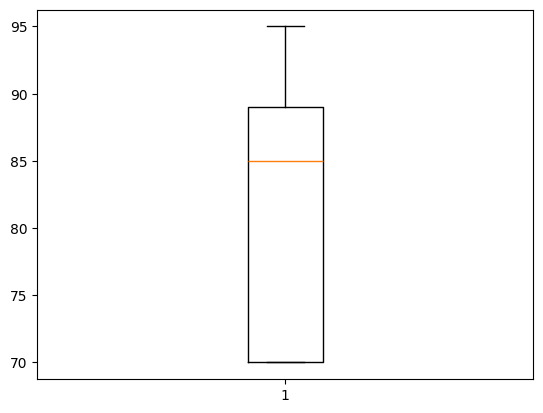

In [89]:
import matplotlib.pyplot as plt

plt.boxplot(df["Marks"].dropna())
plt.show()